In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
try:
  from google.colab import drive
  drive.mount('/content/drive')
  from google.colab import drive
  df=pd.read_excel('/content/drive/MyDrive/Colab Notebooks/Project_ExcelR/World_development_mesurement.xlsx',sheet_name=0)
  # Show first few rows
  print(df.head())
except FileNotFoundError:
  print("Drive not found. Verify your Google Drive path.")

Mounted at /content/drive
   Birth Rate Business Tax Rate  CO2 Emissions       Country  \
0       0.020               NaN        87931.0       Algeria   
1       0.050               NaN         9542.0        Angola   
2       0.043               NaN         1617.0         Benin   
3       0.027               NaN         4276.0      Botswana   
4       0.046               NaN         1041.0  Burkina Faso   

   Days to Start Business  Ease of Business  Energy Usage              GDP  \
0                     NaN               NaN       26998.0  $54,790,058,957   
1                     NaN               NaN        7499.0   $9,129,594,819   
2                     NaN               NaN        1983.0   $2,359,122,303   
3                     NaN               NaN        1836.0   $5,788,311,645   
4                     NaN               NaN           NaN   $2,610,959,139   

   Health Exp % GDP Health Exp/Capita  ...  Life Expectancy Male  \
0             0.035               $60  ...          

In [2]:
# Show column names and data types
print(df.dtypes)



Birth Rate                float64
Business Tax Rate          object
CO2 Emissions             float64
Country                    object
Days to Start Business    float64
Ease of Business          float64
Energy Usage              float64
GDP                        object
Health Exp % GDP          float64
Health Exp/Capita          object
Hours to do Tax           float64
Infant Mortality Rate     float64
Internet Usage            float64
Lending Interest          float64
Life Expectancy Female    float64
Life Expectancy Male      float64
Mobile Phone Usage        float64
Number of Records           int64
Population 0-14           float64
Population 15-64          float64
Population 65+            float64
Population Total            int64
Population Urban          float64
Tourism Inbound            object
Tourism Outbound           object
dtype: object


In [3]:
 # Optional: check for non-numeric values in supposed numeric columns
for col in df.columns:
    print(col, df[col].apply(type).value_counts())#Check data types inside each column
print("Columns after loading:", df.columns.tolist())
print("Shape:", df.shape)#Print dataset shape rows columns

Birth Rate Birth Rate
<class 'float'>    2704
Name: count, dtype: int64
Business Tax Rate Business Tax Rate
<class 'str'>      1423
<class 'float'>    1281
Name: count, dtype: int64
CO2 Emissions CO2 Emissions
<class 'float'>    2704
Name: count, dtype: int64
Country Country
<class 'str'>    2704
Name: count, dtype: int64
Days to Start Business Days to Start Business
<class 'float'>    2704
Name: count, dtype: int64
Ease of Business Ease of Business
<class 'float'>    2704
Name: count, dtype: int64
Energy Usage Energy Usage
<class 'float'>    2704
Name: count, dtype: int64
GDP GDP
<class 'str'>      2494
<class 'float'>     210
Name: count, dtype: int64
Health Exp % GDP Health Exp % GDP
<class 'float'>    2704
Name: count, dtype: int64
Health Exp/Capita Health Exp/Capita
<class 'str'>      2395
<class 'float'>     309
Name: count, dtype: int64
Hours to do Tax Hours to do Tax
<class 'float'>    2704
Name: count, dtype: int64
Infant Mortality Rate Infant Mortality Rate
<class 'float'>   

274 rows and 25 columns

In [4]:
#check dataset
df.info()
df.describe()
df.isnull().sum()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2704 entries, 0 to 2703
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Birth Rate              2585 non-null   float64
 1   Business Tax Rate       1423 non-null   object 
 2   CO2 Emissions           2125 non-null   float64
 3   Country                 2704 non-null   object 
 4   Days to Start Business  1718 non-null   float64
 5   Ease of Business        185 non-null    float64
 6   Energy Usage            1785 non-null   float64
 7   GDP                     2494 non-null   object 
 8   Health Exp % GDP        2395 non-null   float64
 9   Health Exp/Capita       2395 non-null   object 
 10  Hours to do Tax         1416 non-null   float64
 11  Infant Mortality Rate   2444 non-null   float64
 12  Internet Usage          2531 non-null   float64
 13  Lending Interest        1880 non-null   float64
 14  Life Expectancy Female  2568 non-null   

,0
Birth Rate,119
Business Tax Rate,1281
CO2 Emissions,579
Country,0
Days to Start Business,986
Ease of Business,2519
Energy Usage,919
GDP,210
Health Exp % GDP,309
Health Exp/Capita,309


In [5]:
#handle missing value
df.fillna(df.mean(numeric_only=True), inplace=True)




In [6]:
#check duplicates rows
df.drop_duplicates(inplace=True)
df.isnull().sum()




,0
Birth Rate,0
Business Tax Rate,1281
CO2 Emissions,0
Country,0
Days to Start Business,0
Ease of Business,0
Energy Usage,0
GDP,210
Health Exp % GDP,0
Health Exp/Capita,309


In [7]:
#remove columns,it does not have any value in all rows
df.dropna(axis=1, how='all', inplace=True)
df.isnull().sum()



,0
Birth Rate,0
Business Tax Rate,1281
CO2 Emissions,0
Country,0
Days to Start Business,0
Ease of Business,0
Energy Usage,0
GDP,210
Health Exp % GDP,0
Health Exp/Capita,309


In [8]:
# Store country names
countries = df['Country']
#Remove rows with more than 6 values are NAN
df = df.dropna(thresh=len(df.columns)-6)
df.isnull().sum()

#Keep rows with 14 or more valid values
df = df.dropna(thresh=14)
df.isnull().sum()

,0
Birth Rate,0
Business Tax Rate,1281
CO2 Emissions,0
Country,0
Days to Start Business,0
Ease of Business,0
Energy Usage,0
GDP,210
Health Exp % GDP,0
Health Exp/Capita,309


In [9]:
#Remove rows with more than 6 values are NAN
df = df.dropna(thresh=len(df.columns)-6)
df.isnull().sum()



,0
Birth Rate,0
Business Tax Rate,1281
CO2 Emissions,0
Country,0
Days to Start Business,0
Ease of Business,0
Energy Usage,0
GDP,210
Health Exp % GDP,0
Health Exp/Capita,309


In [10]:
#Keep rows with 14 or more valid values
df = df.dropna(thresh=14)
df.isnull().sum()

,0
Birth Rate,0
Business Tax Rate,1281
CO2 Emissions,0
Country,0
Days to Start Business,0
Ease of Business,0
Energy Usage,0
GDP,210
Health Exp % GDP,0
Health Exp/Capita,309


In [11]:
#nothing in Business Tax rate
df.drop('Business Tax Rate', axis=1, inplace=True)
df.isnull().sum()

,0
Birth Rate,0
CO2 Emissions,0
Country,0
Days to Start Business,0
Ease of Business,0
Energy Usage,0
GDP,210
Health Exp % GDP,0
Health Exp/Capita,309
Hours to do Tax,0


In [12]:
#remove currency symbols
df['GDP'] = df['GDP'].replace(r'[\$,]', '', regex=True).astype(float)
df['Health Exp/Capita'] = df['Health Exp/Capita'].replace(r'[\$,]', '', regex=True).astype(float)
df['Tourism Inbound'] = df['Tourism Inbound'].replace(r'[\$,]', '', regex=True).astype(float)
df['Tourism Outbound'] = df['Tourism Outbound'].replace(r'[\$,]', '', regex=True).astype(float)

#convert to numeric
df['GDP'] = pd.to_numeric(df['GDP'], errors='coerce')
df['Health Exp/Capita'] = pd.to_numeric(df['Health Exp/Capita'], errors='coerce')
df['Tourism Inbound'] = pd.to_numeric(df['Tourism Inbound'], errors='coerce')
df['Tourism Outbound'] = pd.to_numeric(df['Tourism Outbound'], errors='coerce')

#missing values handle
df.fillna(df.mean(numeric_only=True), inplace=True)
df.isnull().sum()

,0
Birth Rate,0
CO2 Emissions,0
Country,0
Days to Start Business,0
Ease of Business,0
Energy Usage,0
GDP,0
Health Exp % GDP,0
Health Exp/Capita,0
Hours to do Tax,0


In [13]:
df.dtypes

,0
Birth Rate,float64
CO2 Emissions,float64
Country,object
Days to Start Business,float64
Ease of Business,float64
Energy Usage,float64
GDP,float64
Health Exp % GDP,float64
Health Exp/Capita,float64
Hours to do Tax,float64


In [14]:
#Remove % from the Dataset
df = df.replace('%','', regex=True)
df = df.apply(pd.to_numeric, errors='ignore')
df = df.fillna(df.mean(numeric_only=True))

X = df.drop('Country', axis=1)





/tmp/ipykernel_12902/3459727521.py:3: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


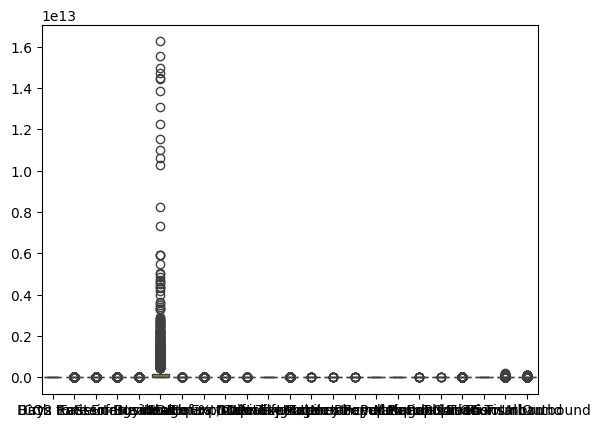

In [15]:
#remove outliers
sns.boxplot(data=df)
plt.show()



In [16]:
#IQR method
df_numeric = df.select_dtypes(include=[np.number])
Q1 = df_numeric.quantile(0.25)
Q3 = df_numeric.quantile(0.75)
IQR = Q3 - Q1
outliers = df_numeric[(df_numeric < (Q1 - 1.5 * IQR)) | (df_numeric > (Q3 + 1.5 * IQR))]
print(outliers)





      Birth Rate  CO2 Emissions  Days to Start Business  Ease of Business  \
0            NaN            NaN                     NaN               NaN   
1            NaN            NaN                     NaN               NaN   
2            NaN            NaN                     NaN               NaN   
3            NaN            NaN                     NaN               NaN   
4            NaN            NaN                     NaN               NaN   
...          ...            ...                     ...               ...   
2699         NaN            NaN                     NaN               NaN   
2700         NaN            NaN                     NaN               4.0   
2701         NaN            NaN                     NaN              85.0   
2702         NaN            NaN                   144.0             180.0   
2703         NaN            NaN                     NaN               NaN   

      Energy Usage           GDP  Health Exp % GDP  Health Exp/Capita  \
0 

In [17]:
#percentage of outliers
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    percent = (len(outliers) / len(df)) * 100

    print(f"{col}: {percent:.2f}% outliers")

Birth Rate: 0.00% outliers
CO2 Emissions: 6.51% outliers
Days to Start Business: 7.88% outliers
Ease of Business: 6.84% outliers
Energy Usage: 5.84% outliers
GDP: 8.80% outliers
Health Exp % GDP: 2.14% outliers
Health Exp/Capita: 11.72% outliers
Hours to do Tax: 17.57% outliers
Infant Mortality Rate: 1.81% outliers
Internet Usage: 0.00% outliers
Lending Interest: 9.06% outliers
Life Expectancy Female: 0.52% outliers
Life Expectancy Male: 0.41% outliers
Mobile Phone Usage: 0.41% outliers
Number of Records: 0.00% outliers
Population 0-14: 0.00% outliers
Population 15-64: 0.33% outliers
Population 65+: 0.18% outliers
Population Total: 11.76% outliers
Population Urban: 0.00% outliers
Tourism Inbound: 9.02% outliers
Tourism Outbound: 8.32% outliers


In [18]:
df.isnull().sum().sort_values(ascending=False)

,0
Birth Rate,0
CO2 Emissions,0
Country,0
Days to Start Business,0
Ease of Business,0
Energy Usage,0
GDP,0
Health Exp % GDP,0
Health Exp/Capita,0
Hours to do Tax,0


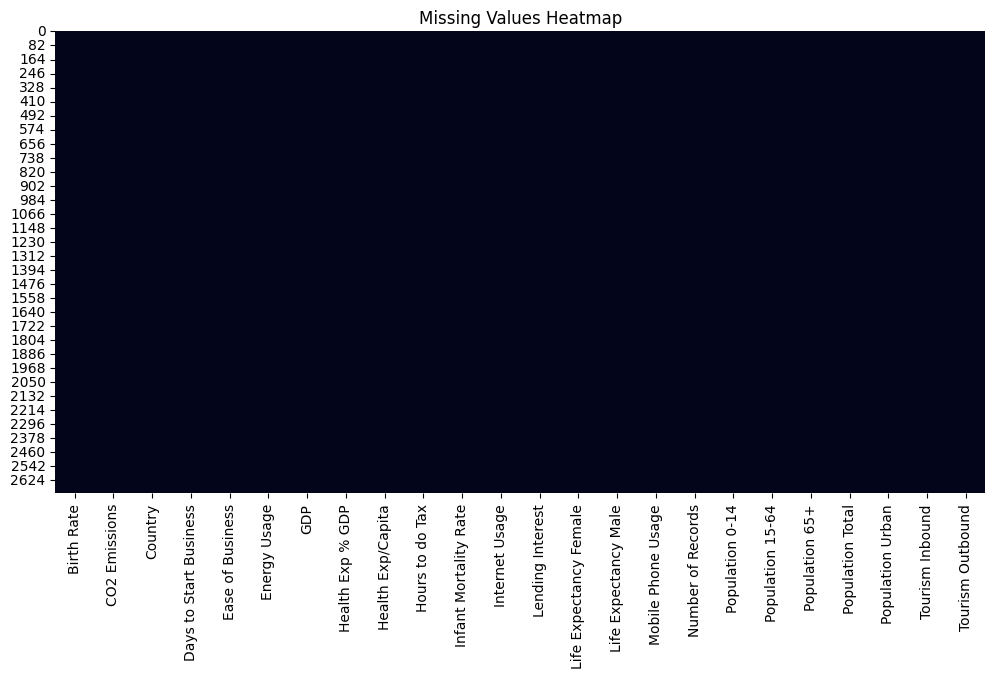

In [19]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()
#No missing

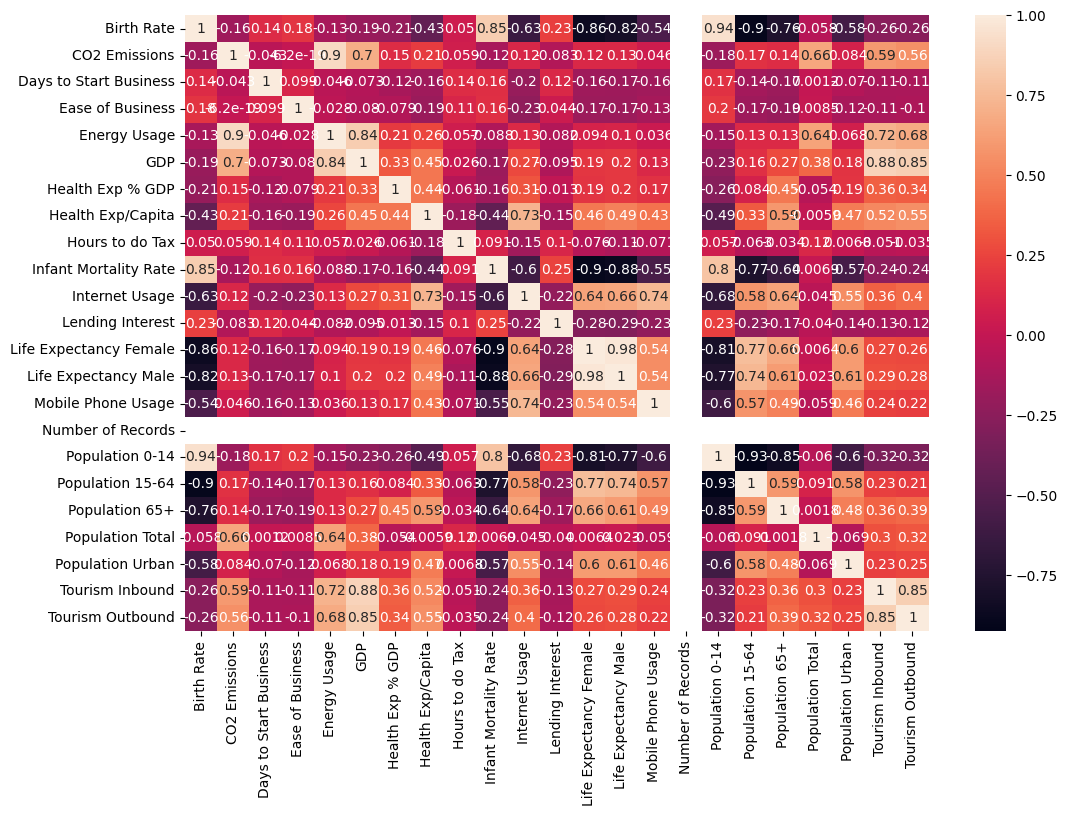

In [20]:
#remove unnecessary columns
#country_names = df['Country']
#df = df.drop('Country', axis=1)
#correlation analysis
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

1. Strong Positive Correlations (close to +1)

These variables increase together:

GDP ↔ Energy Usage (~0.84)
→ Richer countries use more energy

GDP ↔ Health Exp/Capita (~0.45+)
→ Higher GDP → more spending on health

Life Expectancy (Male & Female) ↔ GDP / Health
→ Better economy & healthcare → people live longer

Internet Usage ↔ Mobile Phone Usage (~0.74)
→ Technology access grows together

Tourism Inbound ↔ Tourism Outbound (~0.85)
→ Countries active in tourism tend to both send & receive travelers

2. Strong Negative Correlations (close to -1)

These move in opposite directions:

Birth Rate ↔ Life Expectancy (~ -0.85)
→ Countries with high birth rates often have lower life expectancy

Infant Mortality Rate ↔ Life Expectancy (~ -0.8 to -0.9)
→ More infant deaths → lower overall lifespan

Birth Rate ↔ GDP (~ -0.7 approx)
→ Developed countries → lower birth rates

3. Moderate Relationships

CO₂ Emissions ↔ GDP (~0.7)
→ Industrial growth increases emissions

Urban Population ↔ Energy Usage / GDP
→ Urbanization linked with development

4. Weak / No Correlation (around 0)

Variables like:

Days to Start Business

Ease of Business

→ These don’t strongly relate to most others in your dataset

Key Insight (Very Important for ML)
Multicollinearity

Some variables are highly correlated:

GDP, Energy Usage, Health Exp, Life Expectancy

This can affect:

Linear Regression

PCA

Feature importance

Developed countries pattern:

High GDP

High life expectancy

High tech usage

Low birth & infant mortality

Developing countries pattern:

High birth rate

Higher infant mortality

Lower GDP & healthcare

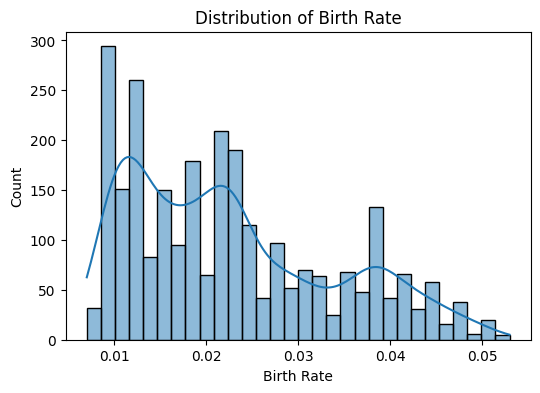

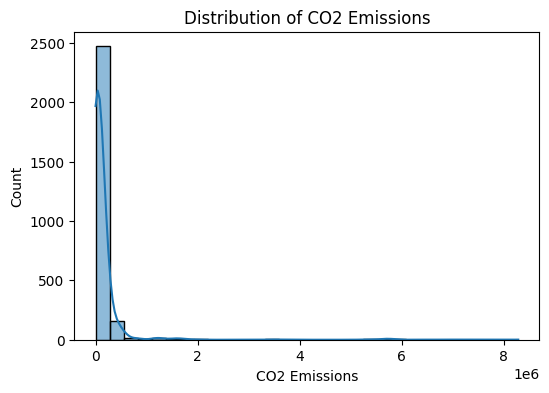

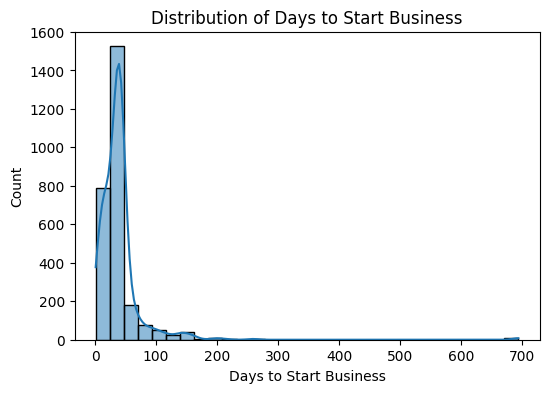

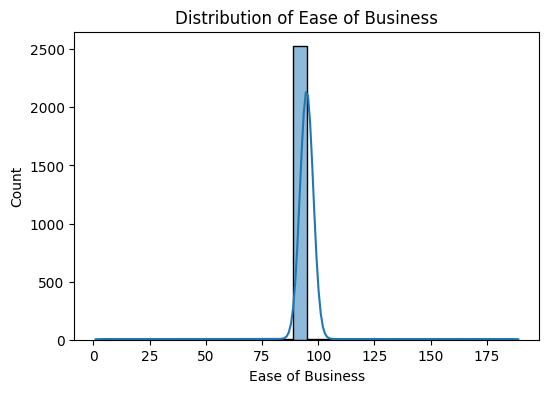

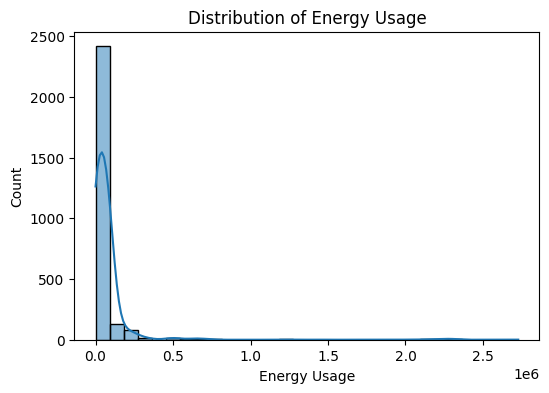

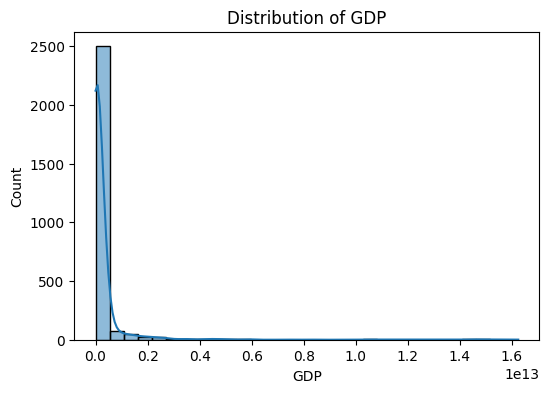

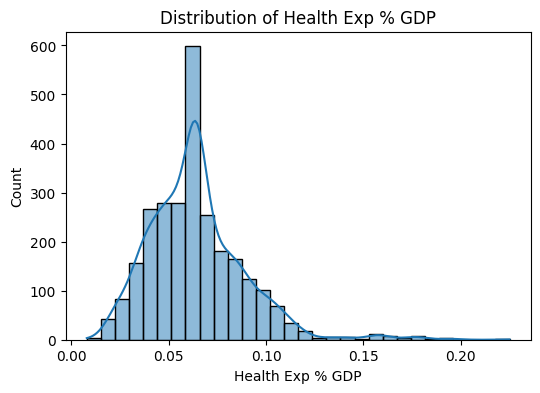

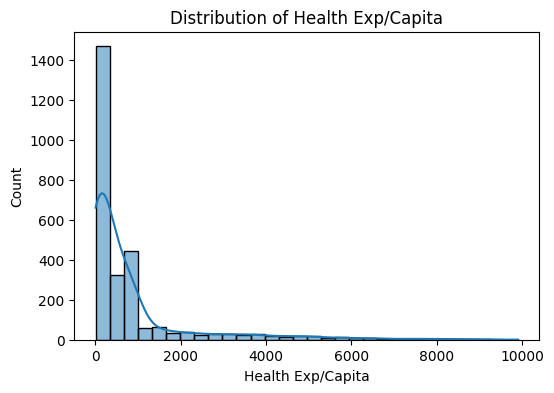

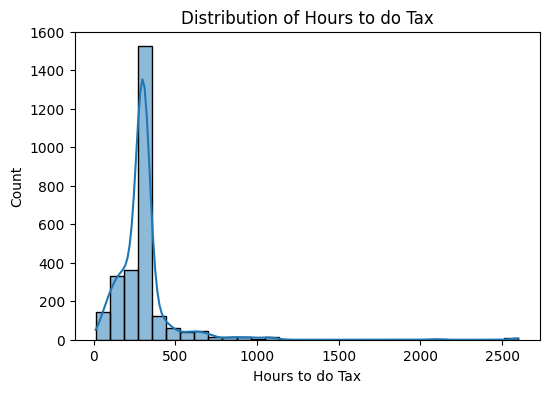

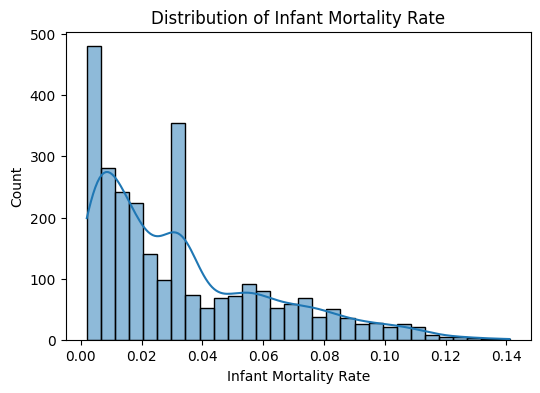

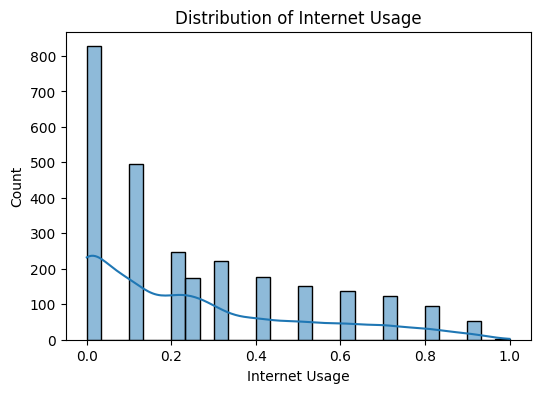

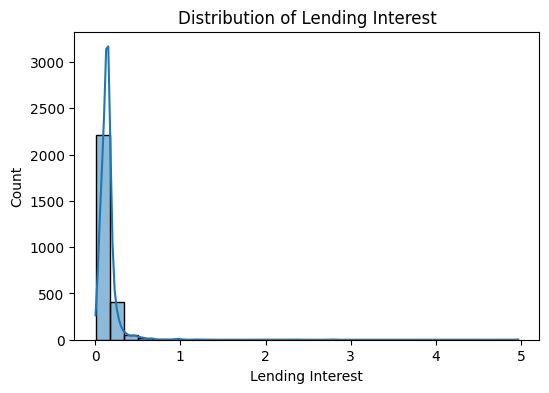

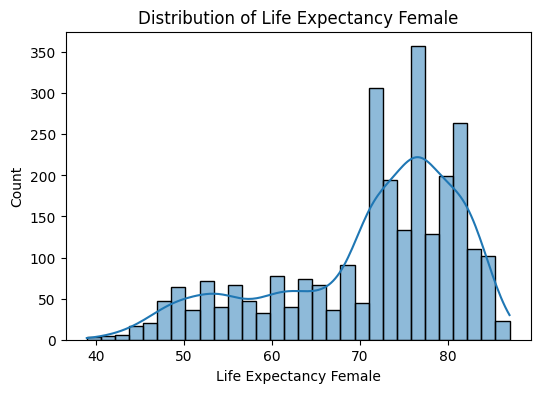

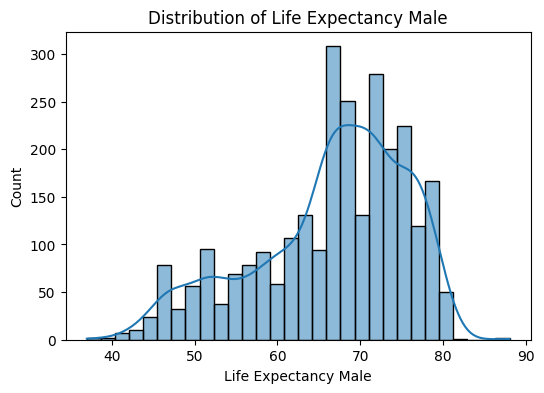

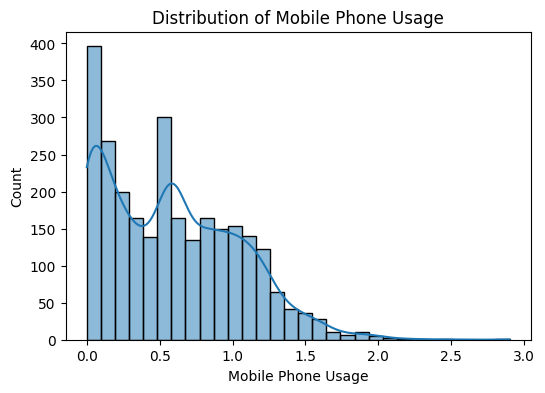

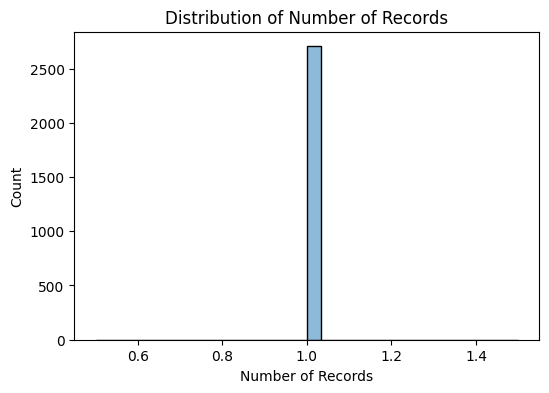

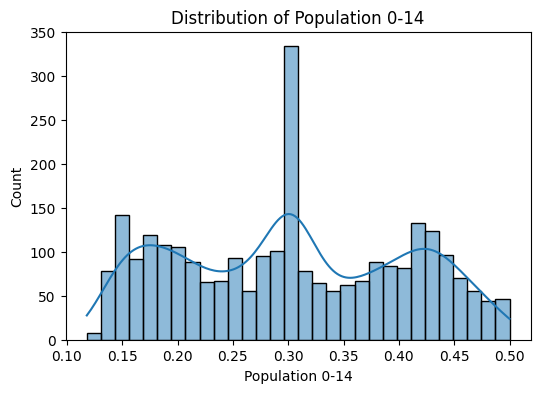

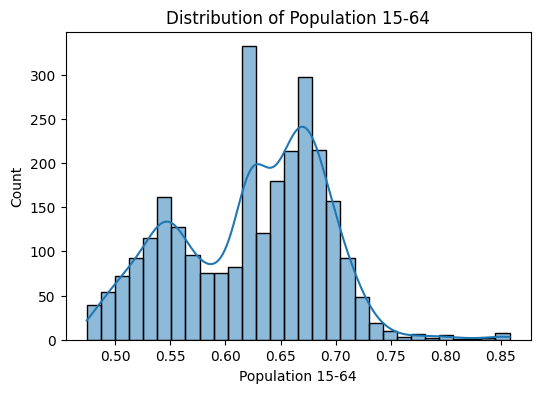

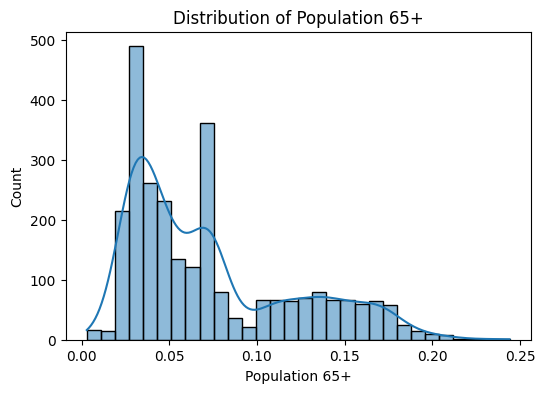

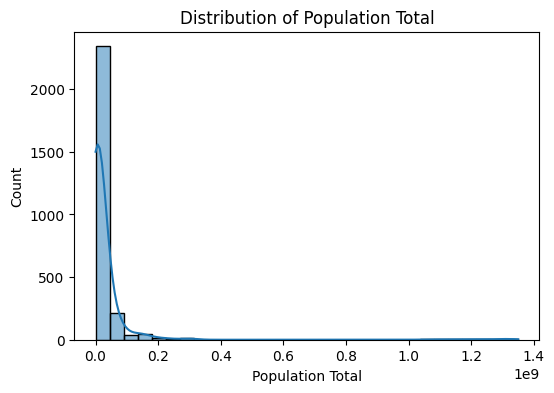

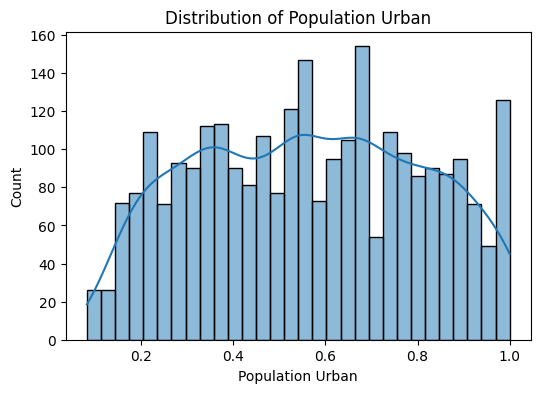

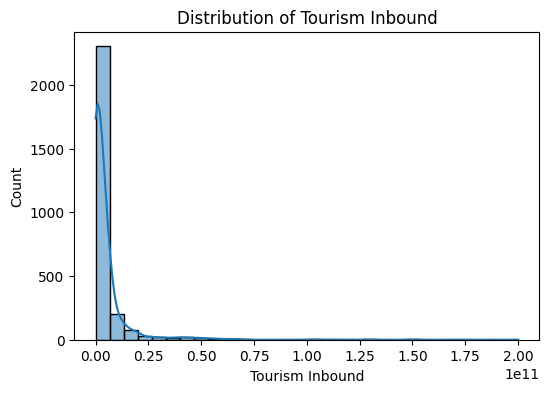

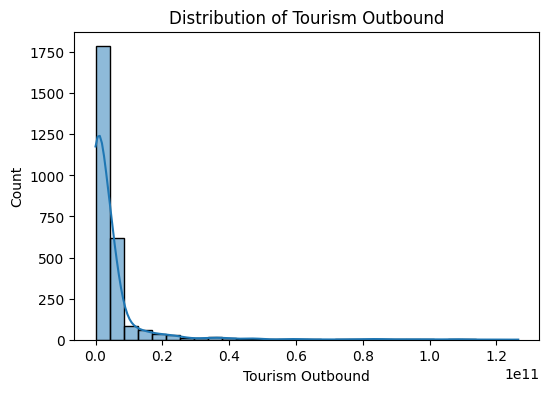

In [21]:
#visualization to understand skewness
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

Most are positively skewed so modeling is log transformation

The histogram is right-skewed (positively skewed)
→ Most countries have lower birth rates, and a few have very high birth rates

Shape of data

Normal (bell-shaped)

Skewed (left/right)

Outliers

Extreme values far from others

Spread of data

Narrow vs wide distribution

Data issues

Too many zeros

Strange spikes

Distribution analysis shows that several variables such as GDP, CO₂ emissions, and energy usage are positively skewed, indicating that a small number of countries have significantly higher values than others. Variables like life expectancy and birth rate appear more normally distributed. Since the dataset contains variables with different scales and distributions, feature scaling will be required before applying clustering algorithms.

**Why This Matters for Clustering**

Algorithms like K-Means use distance calculations.

If one variable (e.g., GDP) has values up to 50,000 and another (e.g., birth rate) ranges 10–40, GDP will dominate the clustering.

So after distribution analysis we usually apply:

StandardScaler

MinMaxScaler

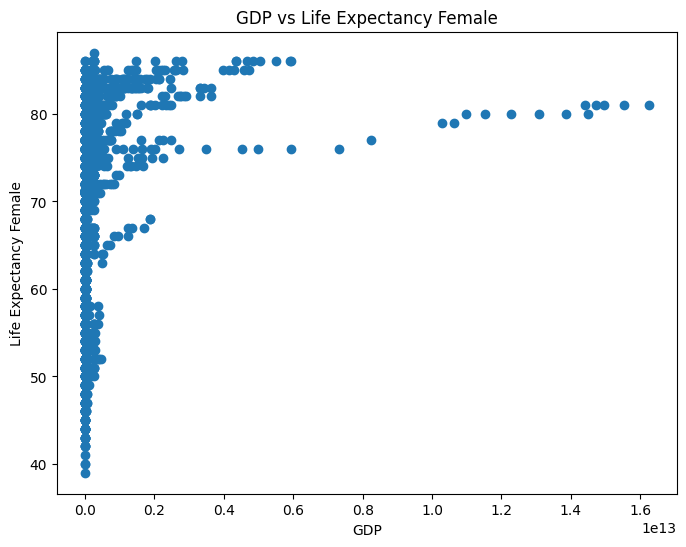

In [22]:

plt.figure(figsize=(8,6))
plt.scatter(df['GDP'], df['Life Expectancy Female'])
plt.xlabel('GDP')
plt.ylabel('Life Expectancy Female')
plt.title('GDP vs Life Expectancy Female')
plt.show()

GDP and female life expectancy are positively related The relationship shows diminishing returnsHigh GDP countries have consistently high life expectancy, while low GDP countries show more variation

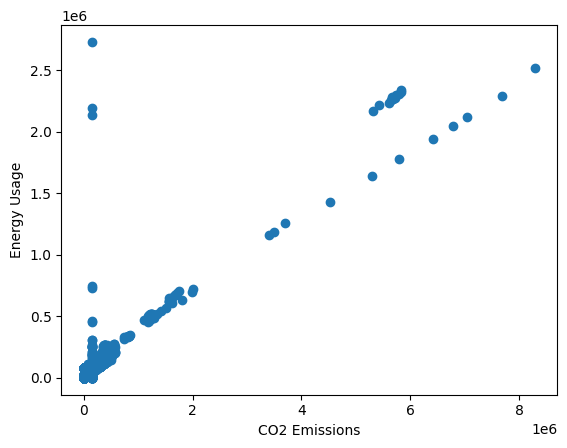

In [23]:
plt.scatter(df['CO2 Emissions'], df['Energy Usage'])
plt.xlabel('CO2 Emissions')
plt.ylabel('Energy Usage')
plt.show()

CO₂ emissions and energy usage have a strong positive linear relationship
Higher energy consumption leads to higher emissions
Some exceptions suggest differences in energy sources (clean vs fossil)

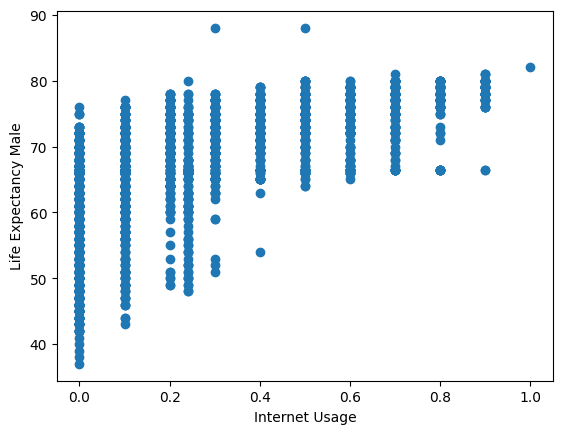

In [24]:
plt.scatter(df['Internet Usage'], df['Life Expectancy Male'])
plt.xlabel('Internet Usage')
plt.ylabel('Life Expectancy Male')
plt.show()

Internet usage and male life expectancy show a positive relationship
 Higher internet access is associated with higher and more stable life expectancy
Low internet usage countries show greater variability and lower lifespan

In [25]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
print(num_cols)

Index(['Birth Rate', 'CO2 Emissions', 'Days to Start Business',
       'Ease of Business', 'Energy Usage', 'GDP', 'Health Exp % GDP',
       'Health Exp/Capita', 'Hours to do Tax', 'Infant Mortality Rate',
       'Internet Usage', 'Lending Interest', 'Life Expectancy Female',
       'Life Expectancy Male', 'Mobile Phone Usage', 'Number of Records',
       'Population 0-14', 'Population 15-64', 'Population 65+',
       'Population Total', 'Population Urban', 'Tourism Inbound',
       'Tourism Outbound'],
      dtype='object')


In [26]:
#Find skewness of all numeric columns
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

skewness = df[numeric_cols].skew()
print(skewness)

Birth Rate                 0.677203
CO2 Emissions              9.760611
Days to Start Business     9.327939
Ease of Business           0.067326
Energy Usage               8.689642
GDP                        9.812540
Health Exp % GDP           1.253465
Health Exp/Capita          2.993509
Hours to do Tax            6.203334
Infant Mortality Rate      1.103447
Internet Usage             0.972557
Lending Interest          18.627787
Life Expectancy Female    -0.914833
Life Expectancy Male      -0.723904
Mobile Phone Usage         0.588033
Number of Records          0.000000
Population 0-14            0.062242
Population 15-64          -0.194971
Population 65+             0.959664
Population Total           8.788164
Population Urban           0.012579
Tourism Inbound            7.654133
Tourism Outbound           5.732858
dtype: float64


In [27]:
#select right skewed >0.5 and >1
right_skewed = skewness[skewness > 1].index
print(right_skewed)

Index(['CO2 Emissions', 'Days to Start Business', 'Energy Usage', 'GDP',
       'Health Exp % GDP', 'Health Exp/Capita', 'Hours to do Tax',
       'Infant Mortality Rate', 'Lending Interest', 'Population Total',
       'Tourism Inbound', 'Tourism Outbound'],
      dtype='object')


In [28]:
#check for +ve values
print(df[right_skewed].min())

CO2 Emissions             7.000000e+00
Days to Start Business    1.000000e+00
Energy Usage              8.000000e+00
GDP                       6.310127e+07
Health Exp % GDP          8.000000e-03
Health Exp/Capita         2.000000e+00
Hours to do Tax           1.200000e+01
Infant Mortality Rate     2.000000e-03
Lending Interest          5.000000e-03
Population Total          1.887600e+04
Tourism Inbound           7.000000e+05
Tourism Outbound          2.000000e+05
dtype: float64


In [29]:
#check -ve skewed
neg_skewed = skewness[skewness < -1].index
print(neg_skewed)

Index([], dtype='object')


In [30]:
#Log transformation for right skewed-Log transformation is used to reduce skewness and scale down large values
for col in right_skewed:
    print(col)
    print("Before:", skewness[col])
    print("After:", np.log1p(df[col]).skew())

CO2 Emissions
Before: 9.760610974593073
After: -0.3868234567378948
Days to Start Business
Before: 9.32793877345987
After: -0.41002236366122785
Energy Usage
Before: 8.689642169441612
After: -1.0943383984806294
GDP
Before: 9.812540438051208
After: 0.04715141349161966
Health Exp % GDP
Before: 1.2534646232397018
After: 1.1166623689356618
Health Exp/Capita
Before: 2.9935094898958834
After: -0.03841645130819925
Hours to do Tax
Before: 6.203333984125752
After: -0.8949147731680183
Infant Mortality Rate
Before: 1.103447283256992
After: 1.0518815519257478
Lending Interest
Before: 18.627787098128902
After: 6.828693998052734
Population Total
Before: 8.788164352982424
After: -0.37178334610379504
Tourism Inbound
Before: 7.654132501838539
After: -0.4959581620205573
Tourism Outbound
Before: 5.732858208224498
After: -0.38756660985848035


In [31]:
df.dtypes

,0
Birth Rate,float64
CO2 Emissions,float64
Country,object
Days to Start Business,float64
Ease of Business,float64
Energy Usage,float64
GDP,float64
Health Exp % GDP,float64
Health Exp/Capita,float64
Hours to do Tax,float64


In [32]:
#check updated skewness
df_numeric = df.select_dtypes(include=['int64','float64'])
df.drop('Country', axis=1, inplace=True)
df.skew()
#Between -0.5 to +0.5 → very good (almost normal)

#Between -1 to +1 → acceptable

,0
Birth Rate,0.677203
CO2 Emissions,9.760611
Days to Start Business,9.327939
Ease of Business,0.067326
Energy Usage,8.689642
GDP,9.812540
Health Exp % GDP,1.253465
Health Exp/Capita,2.993509
Hours to do Tax,6.203334
Infant Mortality Rate,1.103447


Highly Right-Skewed ( must transform)

(> 1)

CO2 Emissions → 9.76

Days to Start Business → 9.32

Energy Usage → 8.68

GDP → 9.81

Health Exp/Capita → 2.99

Hours to do Tax → 6.20

Infant Mortality Rate → 1.10

Lending Interest → 18.62

Population Total → 8.78

Tourism Inbound → 7.65

Tourism Outbound → 5.73
These are extremely skewed → MUST apply log

Moderately Right-Skewed

(0.5 to 1)

Birth Rate → 0.67

Internet Usage → 0.97

Mobile Phone Usage → 0.58

Population 65+ → 0.95

Approximately Normal

(-0.5 to 0.5)

Ease of Business → 0.06

Population 0–14 → 0.06

Population Urban → 0.01

Number of Records → 0

Negative Skew (acceptable)

Life Expectancy Female → -0.91

Life Expectancy Male → -0.72

Population 15–64 → -0.19
These are:

Mild to moderate left skew
 No need to transform

In [33]:
#log transformation
high_skewed = [
    'CO2 Emissions', 'Days to Start Business', 'Energy Usage', 'GDP',
    'Health Exp/Capita', 'Hours to do Tax', 'Infant Mortality Rate',
    'Lending Interest', 'Population Total',
    'Tourism Inbound', 'Tourism Outbound'
]

for col in high_skewed:
    df[col] = np.log1p(df[col])

In [ ]:
df.skew()

,0
Birth Rate,0.677203
CO2 Emissions,-0.386823
Days to Start Business,-0.410022
Ease of Business,0.067326
Energy Usage,-1.094338
GDP,0.047151
Health Exp % GDP,1.253465
Health Exp/Capita,-0.038416
Hours to do Tax,-0.894915
Infant Mortality Rate,1.051882


In [34]:
#moderate skewed
moderate_skewed = ['Birth Rate', 'Internet Usage', 'Mobile Phone Usage', 'Population 65+']
df['Lending Interest'].clip(upper=df['Lending Interest'].quantile(0.99), inplace=True)#removing extreme high outliers by limiting values to the top 1% boundary.

/tmp/ipykernel_12902/1866734259.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Lending Interest'].clip(upper=df['Lending Interest'].quantile(0.99), inplace=True)


In [38]:
#scalar
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)#You are normalizing your numeric data so all features are on a similar scale.

In [39]:
#convert back to data frame
import pandas as pd
df_scaled = pd.DataFrame(df_scaled, columns=df_numeric.columns)
#adding countries back
#df_scaled['Country'] = countries

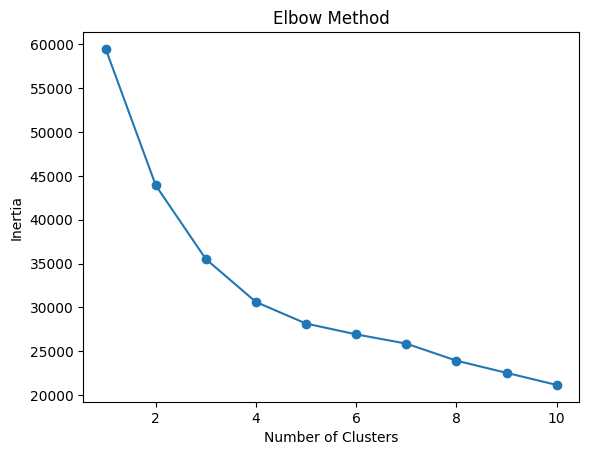

In [40]:
#k-means clustering
from sklearn.cluster import KMeans
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

From K = 1 → 3 → very steep drop 🔻

From K = 3 → 5 → moderate drop

After K = 5 → curve becomes almost flat

so k=3
With K = 3, clusters may represent:

Developed countries

Developing countries

Underdeveloped countries

In [41]:
#apply kmeans
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(df_scaled)
#apply cluster labels
df_scaled['Cluster'] = clusters
#interpret clusters
df_scaled.groupby('Cluster').mean()

,Birth Rate,CO2 Emissions,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,Hours to do Tax,Infant Mortality Rate,...,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.999115,-0.160386,0.206852,0.209121,-0.131585,-0.204306,-0.259996,-0.504564,0.042316,0.941921,...,-0.931472,-0.722310,0.0,1.018492,-0.991200,-0.797361,0.019342,-0.788172,-0.286608,-0.279005
1,-0.648668,-0.031866,-0.132552,-0.134951,-0.058078,0.013505,0.146125,0.302692,-0.032918,-0.613703,...,0.604658,0.480000,0.0,-0.660165,0.640820,0.519174,-0.113201,0.519092,0.085803,0.096636
2,-0.873011,8.561417,-0.288821,-0.233443,9.001469,7.555973,1.631325,1.982330,0.300159,-0.688818,...,0.819707,-0.052816,0.0,-0.957061,1.033941,0.604320,6.215244,0.231906,6.459780,5.476667


Cluster 1 → Developed Countries
Key characteristics:

Low Birth Rate → 0.012 (lowest)

Low Infant Mortality → 0.007 (very low)

High Life Expectancy → ~75 years

High Internet & Mobile Usage → highest

High Health Expenditure per capita

High Population 65+ → aging population

Meaning:Countries with:Strong economy,Advanced healthcare,High technology adoption
Conclusion:
Developed / High-income countries

Cluster 0 → Developing Countries
Key characteristics:

Moderate Birth Rate → 0.018

Moderate Life Expectancy → ~69

Moderate Infant Mortality

Medium Internet & Mobile usage

Average GDP & health spending

Meaning:

Countries in transition:

Improving economy

Growing infrastructure

Moderate living standards

Conclusion:
Developing countries

Cluster 2 → Underdeveloped Countries
Key characteristics:

Highest Birth Rate → 0.036

Highest Infant Mortality → 0.061

Lowest Life Expectancy → ~56

Lowest Mobile & Internet Usage

Lower health expenditure

High population 0–14 (young population)

 Meaning:

Countries with:

Weak healthcare

Low income

High population growth

Conclusion:
Underdeveloped / Low-income countries

Cluster 1 represents developed countries with high life expectancy and low birth rates.
Cluster 0 represents developing countries with moderate indicators.
Cluster 2 represents underdeveloped countries with high birth rates and low life expectancy

In [42]:
print(countries)

0                        Algeria
1                         Angola
2                          Benin
3                       Botswana
4                   Burkina Faso
                  ...           
2699    Turks and Caicos Islands
2700               United States
2701                     Uruguay
2702               Venezuela, RB
2703       Virgin Islands (U.S.)
Name: Country, Length: 2704, dtype: object


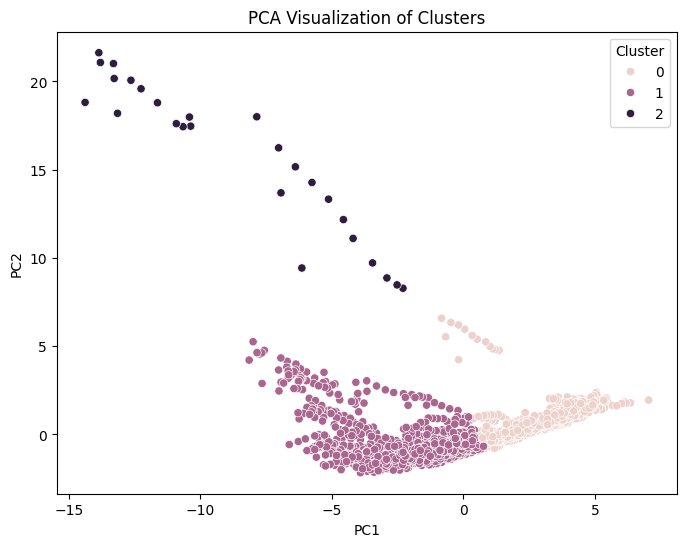

[0.38918236 0.17788516]


In [44]:
#apply PCA Principal Component Analysis-PCA is used to reduce the number of features while keeping most of the important information.
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled.drop('Cluster', axis=1))

#create data frame
import pandas as pd

pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
pca_df['Country'] = countries
#add cluster labels
pca_df['Cluster'] = df_scaled['Cluster']

#plot PCA
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df)

plt.title("PCA Visualization of Clusters")
plt.show()

#variance
print(pca.explained_variance_ratio_)

In [45]:
#with country names
import plotly.express as px
pca_df['Country'] = countries
fig = px.scatter(
    pca_df,
    x='PC1',
    y='PC2',
    color='Cluster',
    hover_name='Country'
)

fig.show()


In [46]:
#Hierarchical clustering
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3)
hc_labels = hc.fit_predict(df_scaled)

In [47]:
#DBScan
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(df_scaled)


In [48]:
#KMeans
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(df_scaled)

In [49]:
#compare using evaluation metric
from sklearn.metrics import silhouette_score

print("KMeans:", silhouette_score(df_scaled, kmeans_labels))
print("Hierarchical:", silhouette_score(df_scaled, hc_labels))

# DBSCAN only if it forms >1 cluster
print("DBSCAN:", silhouette_score(df_scaled, dbscan_labels))

KMeans: 0.32065676409425276
Hierarchical: 0.3140989391270754
DBSCAN: -0.2211762381188723


Closer to +1 → good clustering -Kmeans clustering

Around 0 → overlapping clusters

Negative → bad clustering

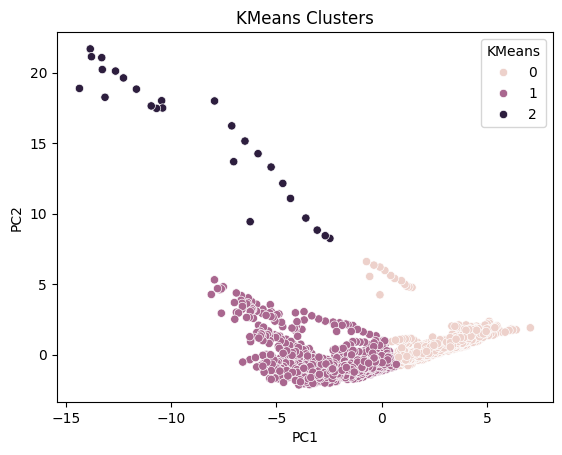

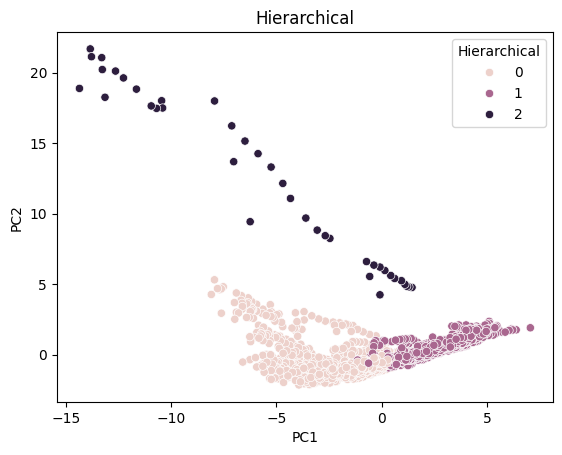

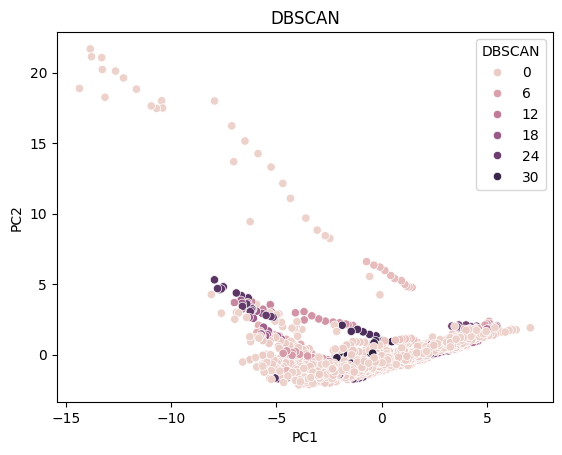

In [56]:
#visualization technique
from sklearn.decomposition import PCA
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pca1 = PCA(n_components=2)
pca1_result = pca.fit_transform(df_scaled)

pca1_df = pd.DataFrame(pca1_result, columns=['PC1','PC2'])

# Add labels
pca1_df['KMeans'] = kmeans_labels
pca1_df['Hierarchical'] = hc_labels
pca1_df['DBSCAN'] = dbscan_labels

sns.scatterplot(x='PC1', y='PC2', hue='KMeans', data=pca1_df)
plt.title("KMeans Clusters")
plt.show()

sns.scatterplot(x='PC1', y='PC2', hue='Hierarchical', data=pca1_df)
plt.title("Hierarchical")
plt.show()
sns.scatterplot(x='PC1', y='PC2', hue='DBSCAN', data=pca1_df)
plt.title("DBSCAN")
plt.show()

In [57]:
#save the model for deployment
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

In [58]:
#Deploy in streamlit
#save model
import pickle

# Save scaler and model
pickle.dump(scaler, open('scaler.pkl', 'wb'))
pickle.dump(kmeans, open('kmeans.pkl', 'wb'))

#app.py
import streamlit as st
import pickle
import numpy as np

# Load model
scaler = pickle.load(open('scaler.pkl', 'rb'))
model = pickle.load(open('kmeans.pkl', 'rb'))

st.title("Country Clustering App 🌍")

st.write("Enter country details:")

# Example inputs (adjust based on your features)
gdp = st.number_input("GDP")
life_exp = st.number_input("Life Expectancy Female")
birth_rate = st.number_input("Birth Rate")

# Prediction
if st.button("Predict Cluster"):
    data = np.array([[gdp, life_exp, birth_rate]])
    data_scaled = scaler.transform(data)
    cluster = model.predict(data_scaled)

    st.success(f"This country belongs to Cluster: {cluster[0]}")

2026-03-24 08:26:03.999 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 08:26:04.008 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 08:26:04.011 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 08:26:04.016 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 08:26:04.022 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 08:26:04.027 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 08:26:04.031 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 08:26:04.035 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py
⠸⠼⠴⠦⠧⠇⠏⠋Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 

In [59]:
!curl ipv4.icanhazip.com

34.124.173.84
